In [233]:
import warnings
warnings.filterwarnings("ignore")

In [234]:
import pandas as pd
import numpy as np
import random as rnd

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [235]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
combine = [train_df, test_df]

In [236]:
print(train_df.columns.values)

<StringArray>
['PassengerId',    'Survived',      'Pclass',        'Name',         'Sex',
         'Age',       'SibSp',       'Parch',      'Ticket',        'Fare',
       'Cabin',    'Embarked']
Length: 12, dtype: str


In [237]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [238]:
train_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [239]:
train_df.info()
print('_'*40)
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
________________________________________
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64 

In [240]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [241]:
train_df.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [242]:
train_df[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [243]:
train_df[["Sex", "Survived"]].groupby(['Sex'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [244]:
train_df[["SibSp", "Survived"]].groupby(['SibSp'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [245]:
train_df[["Parch", "Survived"]].groupby(['Parch'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


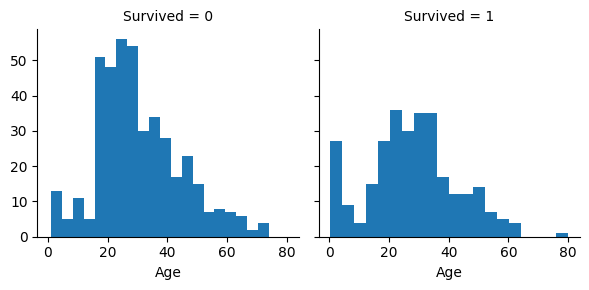

In [246]:
g = sns.FacetGrid(train_df, col='Survived')
g.map(plt.hist, 'Age', bins=20)

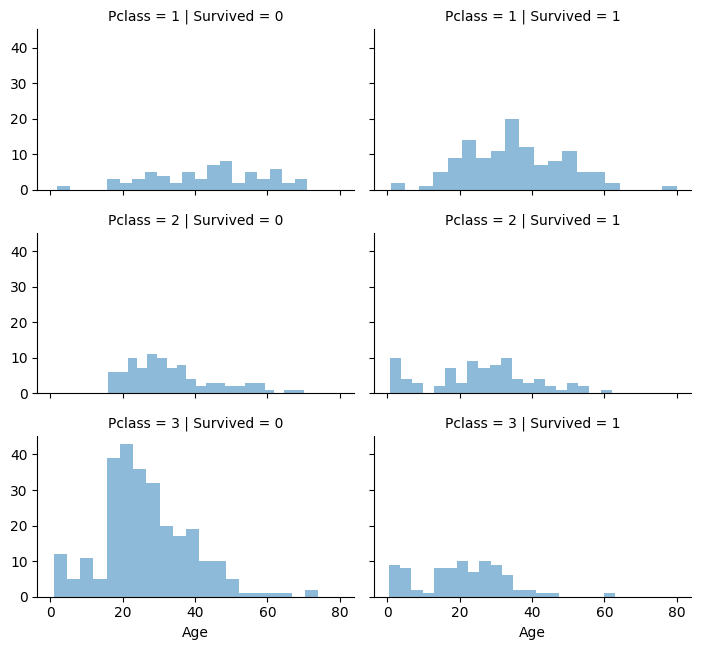

In [247]:
grind = sns.FacetGrid(train_df, col='Survived', row='Pclass', height=2.2, aspect=1.6)
grind.map(plt.hist, 'Age', alpha=.5, bins=20)
grind.add_legend()

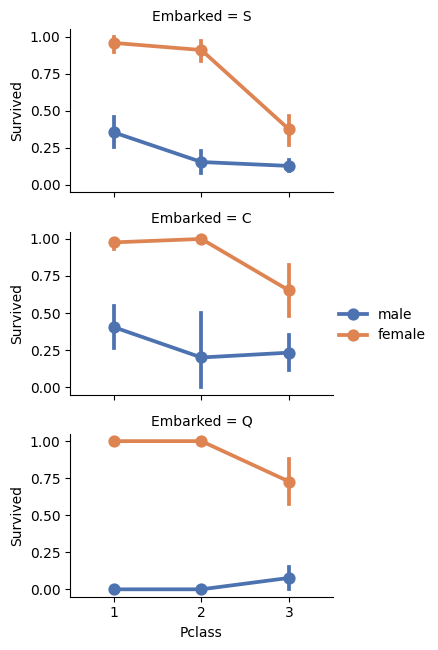

In [248]:
grid = sns.FacetGrid(train_df, row='Embarked', height=2.2, aspect=1.6)
grid.map(sns.pointplot, 'Pclass', 'Survived', 'Sex', order=[1, 2, 3], hue_order=['male', 'female'], palette='deep')
grid.add_legend()

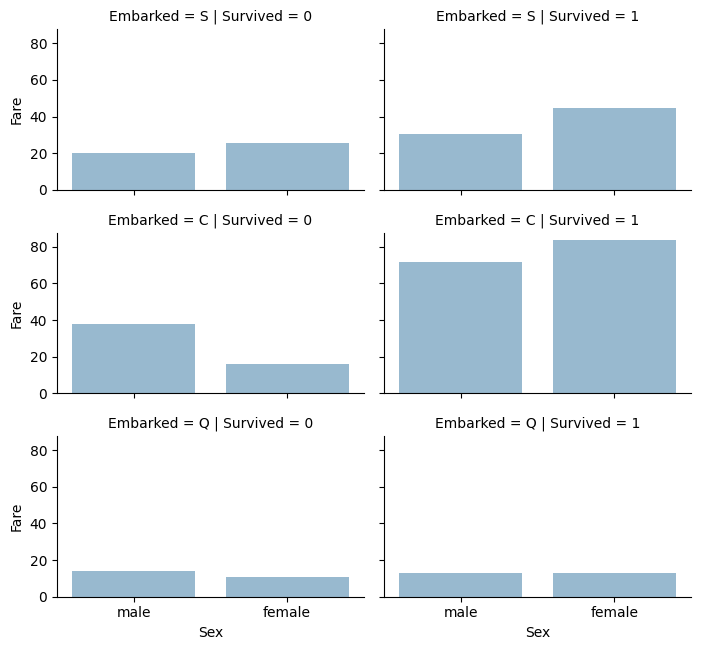

In [249]:
grind = sns.FacetGrid(train_df, row='Embarked', col='Survived', height=2.2, aspect=1.6)
grind.map(sns.barplot, 'Sex', 'Fare', order=['male', 'female'], alpha=.5, errorbar=None)
grind.add_legend()

In [250]:
print("Before", train_df.shape, test_df.shape, combine[0].shape, combine[1].shape)

train_df = train_df.drop(['Ticket', 'Cabin'], axis=1)
test_df = test_df.drop(['Ticket', 'Cabin'], axis=1)
combine = [train_df, test_df]

"After", train_df.shape, test_df.shape, combine[0].shape, combine[1].shape

Before (891, 12) (418, 11) (891, 12) (418, 11)


('After', (891, 10), (418, 9), (891, 10), (418, 9))

In [251]:
for dataset in combine:
    dataset['Title'] = dataset.Name.str.extract(r' ([A-Za-z]+)\.', expand=False)
pd.crosstab(train_df['Title'], train_df['Sex'])

Sex,female,male
Title,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


In [252]:
for dataset in combine:
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Countess','Capt', 'Col',\
 	'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')
    
train_df[['Title', 'Survived']].groupby(['Title'], as_index=False).mean()

,Title,Survived
0,Master,0.575000
1,Miss,0.702703
2,Mr,0.156673
3,Mrs,0.793651
4,Rare,0.347826


In [253]:
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
for dataset in combine:
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,3
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,3
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,1


In [254]:
train_df = train_df.drop(['Name', 'PassengerId'], axis=1)
test_df = test_df.drop(['Name'], axis=1)
combine = [train_df, test_df]
train_df.shape, test_df.shape

((891, 9), (418, 9))

In [255]:
for dataset in combine:
    dataset['Sex'] = dataset['Sex'].map( {'female': 1, 'male': 0} ).astype(int)
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,0,22.0,1,0,7.2500,S,1
1,1,1,1,38.0,1,0,71.2833,C,3
2,1,3,1,26.0,0,0,7.9250,S,2
3,1,1,1,35.0,1,0,53.1000,S,3
4,0,3,0,35.0,0,0,8.0500,S,1


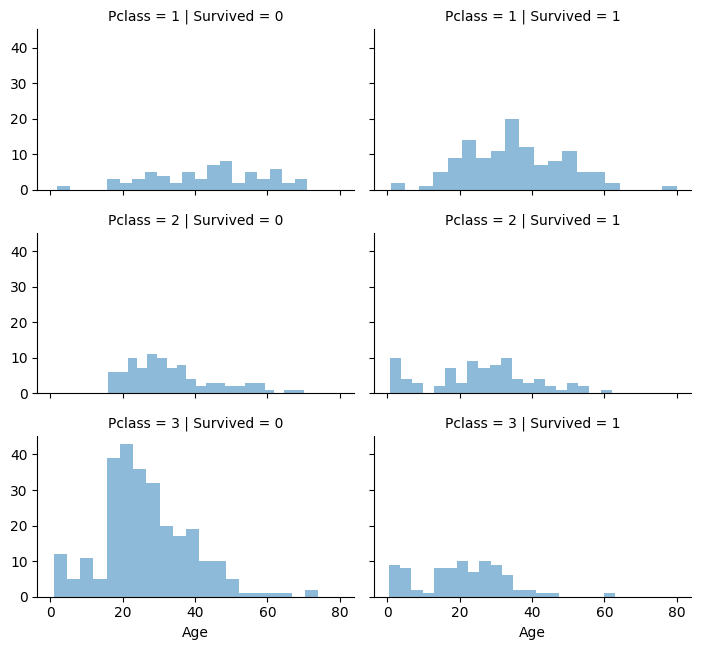

In [256]:
grid = sns.FacetGrid(train_df, col='Survived', row='Pclass', height=2.2, aspect=1.6)
grid.map(plt.hist, 'Age', alpha=.5, bins=20)
grid.add_legend()

In [257]:
guess_ages = np.zeros((2,3))
guess_ages

array([[0., 0., 0.],
       [0., 0., 0.]])

In [258]:
for dataset in combine:
    for i in range(0, 2):
        for j in range(0, 3):
            guess_df = dataset[(dataset['Sex'] == i) & \
                                  (dataset['Pclass'] == j+1)]['Age'].dropna()
            age_guess = guess_df.median()

            guess_ages[i,j] = int( age_guess/0.5 + 0.5 ) * 0.5
            
    for i in range(0, 2):
        for j in range(0, 3):
            dataset.loc[ (dataset.Age.isnull()) & (dataset.Sex == i) & (dataset.Pclass == j+1),\
                    'Age'] = guess_ages[i,j]

    dataset['Age'] = dataset['Age'].astype(int)

train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,0,22,1,0,7.2500,S,1
1,1,1,1,38,1,0,71.2833,C,3
2,1,3,1,26,0,0,7.9250,S,2
3,1,1,1,35,1,0,53.1000,S,3
4,0,3,0,35,0,0,8.0500,S,1


In [259]:
train_df['AgeBand'] = pd.cut(train_df['Age'], 5)
train_df[['AgeBand', 'Survived']].groupby(['AgeBand'], as_index=False).mean().sort_values(by='AgeBand', ascending=True)

,AgeBand,Survived
0,"(-0.08, 16.0]",0.550000
1,"(16.0, 32.0]",0.337374
2,"(32.0, 48.0]",0.412037
3,"(48.0, 64.0]",0.434783
4,"(64.0, 80.0]",0.090909


In [ ]:
for dataset in combine:    
    age_bins = list(range(0, 81, 5)) + [np.inf]
    age_labels = list(range(len(age_bins) - 1))
    dataset['Age'] = pd.cut(dataset['Age'], bins=age_bins, labels=age_labels, right=False).astype('Int64')
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,AgeBand
0,0,3,0,4,1,0,7.2500,S,1,"(16.0, 32.0]"
1,1,1,1,7,1,0,71.2833,C,3,"(32.0, 48.0]"
2,1,3,1,5,0,0,7.9250,S,2,"(16.0, 32.0]"
3,1,1,1,7,1,0,53.1000,S,3,"(32.0, 48.0]"
4,0,3,0,7,0,0,8.0500,S,1,"(32.0, 48.0]"


In [261]:
train_df = train_df.drop(['AgeBand'], axis=1)
combine = [train_df, test_df]
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,0,4,1,0,7.2500,S,1
1,1,1,1,7,1,0,71.2833,C,3
2,1,3,1,5,0,0,7.9250,S,2
3,1,1,1,7,1,0,53.1000,S,3
4,0,3,0,7,0,0,8.0500,S,1


In [262]:
for dataset in combine:
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1

train_df[['FamilySize', 'Survived']].groupby(['FamilySize'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,FamilySize,Survived
3,4,0.724138
2,3,0.578431
1,2,0.552795
6,7,0.333333
0,1,0.303538
4,5,0.200000
5,6,0.136364
7,8,0.000000
8,11,0.000000


In [263]:
for dataset in combine:
    dataset['IsALone'] = 0
    dataset.loc[dataset['FamilySize'] == 1, 'IsALone'] = 1
train_df[['IsALone', 'Survived']].groupby(['IsALone'], as_index=False).mean()

,IsALone,Survived
0,0,0.505650
1,1,0.303538


In [264]:
train_df = train_df.drop(['Parch', 'SibSp', 'FamilySize'], axis=1)
test_df = test_df.drop(['Parch', 'SibSp', 'FamilySize'], axis=1)
combine = [train_df, test_df]
train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,IsALone
0,0,3,0,4,7.2500,S,1,0
1,1,1,1,7,71.2833,C,3,0
2,1,3,1,5,7.9250,S,2,1
3,1,1,1,7,53.1000,S,3,0
4,0,3,0,7,8.0500,S,1,1


In [265]:
for dataset in combine:
    dataset['Age*Class'] = dataset.Age * dataset.Pclass
train_df.loc[:, ['Age*Class', 'Age', 'Pclass']].head(10)

,Age*Class,Age,Pclass
0,12,4,3
1,7,7,1
2,15,5,3
3,7,7,1
4,21,7,3
5,15,5,3
6,10,10,1
7,0,0,3
8,15,5,3
9,4,2,2


In [266]:
freq_port = train_df.Embarked.dropna().mode()[0]
freq_port

'S'

In [267]:
for dataset in combine:
    dataset['Embarked'] = dataset['Embarked'].fillna(freq_port)
train_df[['Embarked', 'Survived']].groupby(['Embarked'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.339009


In [268]:
for dataset in combine:
    dataset['Embarked'] = dataset['Embarked'].map( {'S': 0, 'C': 1, 'Q': 2} ).astype(int)
train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,IsALone,Age*Class
0,0,3,0,4,7.2500,0,1,0,12
1,1,1,1,7,71.2833,1,3,0,7
2,1,3,1,5,7.9250,0,2,1,15
3,1,1,1,7,53.1000,0,3,0,7
4,0,3,0,7,8.0500,0,1,1,21


In [269]:
test_df['Fare'].fillna(test_df['Fare'].dropna().median(), inplace=True)
test_df.head()

,PassengerId,Pclass,Sex,Age,Fare,Embarked,Title,IsALone,Age*Class
0,892,3,0,6,7.8292,2,1,1,18
1,893,3,1,9,7.0000,0,3,0,27
2,894,2,0,12,9.6875,2,1,1,24
3,895,3,0,5,8.6625,0,1,1,15
4,896,3,1,4,12.2875,0,3,0,12


In [270]:
train_df['FareBand'] = pd.qcut(train_df['Fare'], 4)
train_df[['FareBand', 'Survived']].groupby(['FareBand'], as_index=False).mean().sort_values(by='FareBand', ascending=True)

,FareBand,Survived
0,"(-0.001, 7.91]",0.197309
1,"(7.91, 14.454]",0.303571
2,"(14.454, 31.0]",0.454955
3,"(31.0, 512.329]",0.581081


In [271]:
for dataset in combine:
    dataset.loc[ dataset['Fare'] <= 7.91, 'Fare'] = 0
    dataset.loc[(dataset['Fare'] > 7.91) & (dataset['Fare'] <= 14.454), 'Fare'] = 1
    dataset.loc[(dataset['Fare'] > 14.454) & (dataset['Fare'] <= 31), 'Fare']   = 2
    dataset.loc[ dataset['Fare'] > 31, 'Fare'] = 3
    dataset['Fare'] = dataset['Fare'].astype('Int64')

train_df = train_df.drop(['FareBand'], axis=1)
combine = [train_df, test_df]
    
train_df.head(10)

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,IsALone,Age*Class
0,0,3,0,4,0,0,1,0,12
1,1,1,1,7,3,1,3,0,7
2,1,3,1,5,1,0,2,1,15
3,1,1,1,7,3,0,3,0,7
4,0,3,0,7,1,0,1,1,21
5,0,3,0,5,1,2,1,1,15
6,0,1,0,10,3,0,1,1,10
7,0,3,0,0,2,0,4,0,0
8,1,3,1,5,1,0,3,0,15
9,1,2,1,2,2,1,3,0,4


In [272]:
test_df.head(10)

,PassengerId,Pclass,Sex,Age,Fare,Embarked,Title,IsALone,Age*Class
0,892,3,0,6,0,2,1,1,18
1,893,3,1,9,0,0,3,0,27
2,894,2,0,12,1,2,1,1,24
3,895,3,0,5,1,0,1,1,15
4,896,3,1,4,1,0,3,0,12
5,897,3,0,2,1,0,1,1,6
6,898,3,1,6,0,2,2,1,18
7,899,2,0,5,2,0,1,0,10
8,900,3,1,3,0,1,3,1,9
9,901,3,0,4,2,0,1,0,12


In [273]:
X_train = train_df.drop("Survived", axis=1)
Y_train = train_df["Survived"]
X_test = test_df.drop("PassengerId", axis=1).copy()
X_train.shape, Y_train.shape, X_test.shape

((891, 8), (891,), (418, 8))

In [274]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

In [275]:
logreg = LogisticRegression()
logreg.fit(X_train, Y_train)
Y_pred = logreg.predict(X_test)
acc_log = round(logreg.score(X_train, Y_train) * 100, 2)
acc_log

81.37

In [276]:
coeff_df = pd.DataFrame(train_df.columns.delete(0))
coeff_df.columns = ['Feature']
coeff_df["Correlation"] = pd.Series(logreg.coef_[0])

coeff_df.sort_values(by='Correlation', ascending=False)

,Feature,Correlation
1,Sex,2.177534
5,Title,0.394900
4,Embarked,0.289626
6,IsALone,0.250202
7,Age*Class,0.013522
3,Fare,-0.042333
2,Age,-0.199548
0,Pclass,-1.322455


In [277]:
svc = SVC()
svc.fit(X_train, Y_train)
Y_pred = svc.predict(X_test)
acc_svc = round(svc.score(X_train, Y_train) * 100, 2)
acc_svc

79.35

In [278]:
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train, Y_train)
Y_pred = knn.predict(X_test)
acc_knn = round(knn.score(X_train, Y_train) * 100, 2)
acc_knn


86.64

In [279]:
gaussian = GaussianNB()
gaussian.fit(X_train, Y_train)
Y_pred = gaussian.predict(X_test)
acc_gaussian = round(gaussian.score(X_train, Y_train) * 100, 2)
acc_gaussian

76.77

In [280]:
perceptron = Perceptron()
perceptron.fit(X_train, Y_train)
Y_pred = perceptron.predict(X_test)
acc_perceptron = round(perceptron.score(X_train, Y_train) * 100, 2)
acc_perceptron

73.74

In [281]:
linear_svc = LinearSVC()
linear_svc.fit(X_train, Y_train)
Y_pred = linear_svc.predict(X_test)
acc_linear_svc = round(linear_svc.score(X_train, Y_train) * 100, 2)
acc_linear_svc

80.02

In [282]:
sgd = SGDClassifier()
sgd.fit(X_train, Y_train)
Y_pred = sgd.predict(X_test)
acc_sgd = round(sgd.score(X_train, Y_train) * 100, 2)
acc_sgd

80.36

In [283]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, Y_train)
Y_pred = decision_tree.predict(X_test)
acc_decision_tree = round(decision_tree.score(X_train, Y_train) * 100, 2)
acc_decision_tree

90.01

In [284]:
random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, Y_train)
Y_pred = random_forest.predict(X_test)
random_forest.score(X_train, Y_train)
acc_random_forest = round(random_forest.score(X_train, Y_train) * 100, 2)
acc_random_forest

90.01

In [285]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, Y_train)
Y_pred = xgb.predict(X_test)
acc_xgb = round(xgb.score(X_train, Y_train) * 100, 2)
acc_xgb

89.56

In [286]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    random_state=42,
    n_estimators=100,
    num_leaves=31,
    max_depth=6,
    min_child_samples=20,
    min_gain_to_split=0.0,
    verbose=-1
)
lgbm.fit(X_train, Y_train)
Y_pred = lgbm.predict(X_test)
acc_lightgbm = round(lgbm.score(X_train, Y_train) * 100, 2)
acc_lightgbm

87.54

In [287]:
models = pd.DataFrame({
    'Model': ['KNN', 'Random Forest', 'XGBoost', 'LightGBM', 'Naive Bayes', 'Perceptron', 
              'Stochastic Gradient Decent', 'Linear SVC', 
              'Decision Tree'],
    'Score': [acc_knn, 
              acc_random_forest, acc_xgb, acc_lightgbm, acc_gaussian, acc_perceptron, 
              acc_sgd, acc_linear_svc, acc_decision_tree]})
models.sort_values(by='Score', ascending=False)





,Model,Score
1,Random Forest,90.01
8,Decision Tree,90.01
2,XGBoost,89.56
3,LightGBM,87.54
0,KNN,86.64
6,Stochastic Gradient Decent,80.36
7,Linear SVC,80.02
4,Naive Bayes,76.77
5,Perceptron,73.74


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, Y_train, test_size=0.20, random_state=42, stratify=Y_train
)

models = {
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Perceptron': Perceptron(),
    'Linear SVC': LinearSVC(max_iter=10000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SGD': SGDClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_tr, y_tr)

    train_score = model.score(X_tr, y_tr)
    y_val_pred = model.predict(X_val)

    val_acc = accuracy_score(y_val, y_val_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()
    report = classification_report(y_val, y_val_pred, output_dict=True, zero_division=0)

    results.append({
        'Model': name,
        'Training Score': round(train_score * 100, 2),
        'Validation Accuracy': round(val_acc * 100, 2),
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'Precision 0': round(report['0']['precision'] * 100, 2),
        'Recall 0': round(report['0']['recall'] * 100, 2),
        'F1 0': round(report['0']['f1-score'] * 100, 2),
        'Precision 1': round(report['1']['precision'] * 100, 2),
        'Recall 1': round(report['1']['recall'] * 100, 2),
        'F1 1': round(report['1']['f1-score'] * 100, 2)
    })

summary_df = pd.DataFrame(results).sort_values(
    by=['Validation Accuracy', 'Training Score'], ascending=False
)

color_map = {
    'KNN': '#ffccbc',
    'Random Forest': '#c8e6c9',
    'XGBoost': '#b3e5fc',
    'LightGBM': '#ffe082',
    'Naive Bayes': '#d1c4e9',
    'Perceptron': '#ffe0b2',
    'Linear SVC': '#f0f4c3',
    'Decision Tree': '#d7ccc8',
    'SGD': '#f8bbd0'
}

from matplotlib.colors import LinearSegmentedColormap

yellow_cmap = LinearSegmentedColormap.from_list(
    'bright_yellow', ['#ffff99', '#fff176', '#ffeb3b', '#ffd600', '#FFAE00']
)

def color_models(series):
    return [
        f'background-color: {color_map.get(v, "")}; color: black'
        for v in series
    ]

styled = (
    summary_df.style
    .apply(color_models, subset=['Model'])
    .background_gradient(subset=['Validation Accuracy'], cmap='Greens')
    .background_gradient(subset=['Training Score'], cmap='Blues')
    .background_gradient(subset=['TN', 'TP'], cmap=yellow_cmap)
    .background_gradient(subset=['FP', 'FN'], cmap='Reds')
    .background_gradient(subset=['Precision 0', 'Recall 0', 'F1 0', 'Precision 1', 'Recall 1', 'F1 1'], cmap='Purples')
    .format({
        'Training Score': '{:.2f}%',
        'Validation Accuracy': '{:.2f}%',
        'Precision 0': '{:.2f}%',
        'Recall 0': '{:.2f}%',
        'F1 0': '{:.2f}%',
        'Precision 1': '{:.2f}%',
        'Recall 1': '{:.2f}%',
        'F1 1': '{:.2f}%'
    })
    .set_caption('Model training and validation performance')
    .set_properties(**{'text-align': 'center', 'font-weight': '700px'})
)

display(styled)

,Model,Training Score,Validation Accuracy,TN,FP,FN,TP,Precision 0,Recall 0,F1 0,Precision 1,Recall 1,F1 1
3,LightGBM,89.19%,81.01%,97,13,21,48,82.20%,88.18%,85.09%,78.69%,69.57%,73.85%
2,XGBoost,90.45%,79.33%,94,16,21,48,81.74%,85.45%,83.56%,75.00%,69.57%,72.18%
1,Random Forest,90.87%,77.65%,93,17,23,46,80.17%,84.55%,82.30%,73.02%,66.67%,69.70%
6,Linear SVC,81.46%,77.65%,92,18,22,47,80.70%,83.64%,82.14%,72.31%,68.12%,70.15%
7,Decision Tree,90.87%,77.09%,91,19,22,47,80.53%,82.73%,81.61%,71.21%,68.12%,69.63%
4,Naive Bayes,77.53%,74.30%,80,30,16,53,83.33%,72.73%,77.67%,63.86%,76.81%,69.74%
0,KNN,86.24%,71.51%,89,21,30,39,74.79%,80.91%,77.73%,65.00%,56.52%,60.47%
5,Perceptron,62.78%,63.13%,50,60,6,63,89.29%,45.45%,60.24%,51.22%,91.30%,65.62%
8,SGD,49.16%,48.60%,21,89,3,66,87.50%,19.09%,31.34%,42.58%,95.65%,58.93%


### Column Descriptions

- **Model**: The name of the machine learning algorithm used (e.g., KNN, Random Forest).
- **Training Score**: The accuracy percentage of the model on the full training dataset. This measures how well the model fits the training data.
- **Validation Accuracy**: The accuracy percentage on a held-out validation set (20% of training data). This provides a better estimate of real-world performance by avoiding overfitting.
- **TN (True Negatives)**: Number of correctly predicted negative cases (survived = 0).
- **FP (False Positives)**: Number of incorrectly predicted positive cases (predicted survived = 1, but actual = 0).
- **FN (False Negatives)**: Number of incorrectly predicted negative cases (predicted survived = 0, but actual = 1).
- **TP (True Positives)**: Number of correctly predicted positive cases (survived = 1).
- **Precision 0**: Precision for class 0 (did not survive) - the ratio of correctly predicted negatives to total predicted negatives. Measures accuracy of negative predictions.
- **Recall 0**: Recall for class 0 - the ratio of correctly predicted negatives to total actual negatives. Measures how many actual negatives were captured.
- **F1 0**: F1-score for class 0 - harmonic mean of precision and recall for class 0. Balances precision and recall.
- **Precision 1**: Precision for class 1 (survived) - the ratio of correctly predicted positives to total predicted positives.
- **Recall 1**: Recall for class 1 - the ratio of correctly predicted positives to total actual positives.
- **F1 1**: F1-score for class 1 - harmonic mean of precision and recall for class 1.

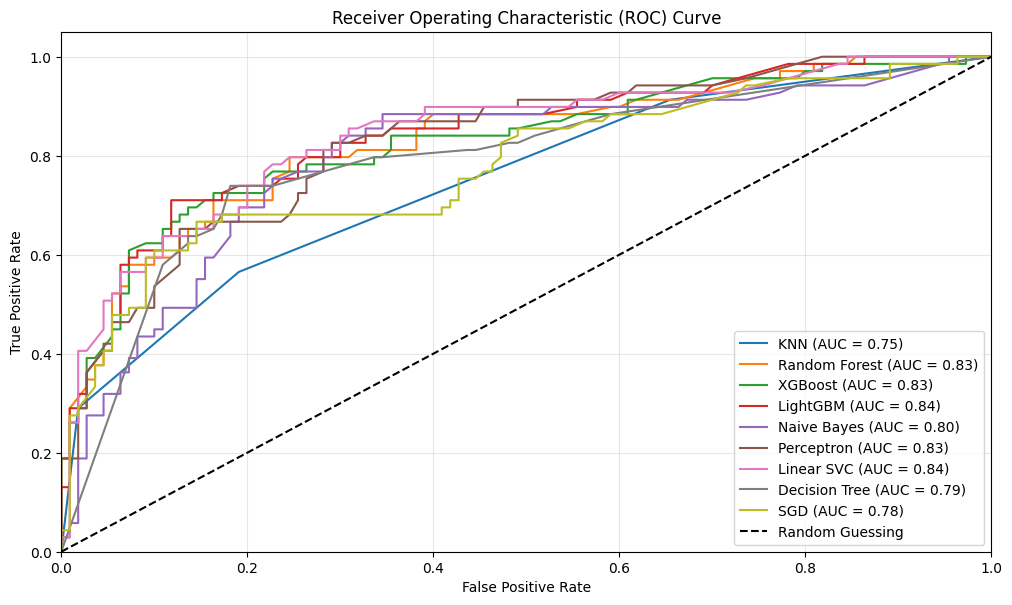

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(14, 9))

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_val)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_val)
    else:
        continue
    
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


In [290]:
sumbission = pd.DataFrame({
        "PassengerId": test_df["PassengerId"],
        "Survived": Y_pred
    })
sumbission.to_csv('submission.csv', index=False)

In [291]:
import pandas as pd

try:
    df = pd.read_csv('submission.csv')
    print("Submission file loaded successfully:")
    print(df.head(10))
    print(f"\nShape: {df.shape}")
except FileNotFoundError:
    print("Error: 'submission.csv' file not found. Please ensure the file exists in the current directory.")
except Exception as e:
    print(f"Error reading the file: {e}")

Submission file loaded successfully:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0

Shape: (418, 2)


## Processed Data Comparison: Clean vs Moving Buckets vs PRAM

This section evaluates all 9 models on three versions of the final processed feature set:
- **Clean Data**: Original processed data without modifications
- **Moving Buckets**: Clean data with bucket-shifting perturbation applied to both Age and Fare columns
- **PRAM**: Clean data with Post Randomization Method applied to both Age and Fare columns

All models are evaluated on the same validation split for fair comparison. AgeClass (Age*Class) is recalculated after Age perturbations in both methods.

In [ ]:
import random
try:
    assert 'X_train' in locals() or 'X_train' in globals()
    assert 'Y_train' in locals() or 'Y_train' in globals()
except AssertionError:
    print("⚠️  X_train or Y_train not found in memory.")
    print("Please run the data preprocessing cells first (cells that load train.csv and create X_train/Y_train)")
    raise NameError("X_train or Y_train not defined. Re-run notebook cells in order.")

clean_X = X_train.copy()

anonymized_X = X_train.copy()

rng = np.random.RandomState(42)
random.seed(42)

def anonymize_bucketed_column(df, column='Age', shift_fraction=0.04):
    """
    Shift 3-5% of bucket values to neighboring buckets (±1 with clipping).
    Assumes the column is already bucketed into discrete integer values.
    """
    df = df.copy()
    if column not in df.columns:
        return df
    
    buckets = sorted(df[column].dropna().unique().astype(int))
    if len(buckets) < 2:
        return df
    
    shift_mask = (rng.rand(len(df)) < shift_fraction) & df[column].notna()
    if not shift_mask.any():
        return df
    
    min_bucket = buckets[0]
    max_bucket = buckets[-1]
    
    shifted_values = []
    for val in df.loc[shift_mask, column].astype(int):
        direction = rng.choice([-1, 1])
        new_val = val + direction
        new_val = max(min_bucket, min(new_val, max_bucket))
        shifted_values.append(new_val)
    
    df.loc[shift_mask, column] = shifted_values
    return df
anonymized_X = anonymize_bucketed_column(anonymized_X, 'Age', shift_fraction=0.04)

if 'Age*Class' in anonymized_X.columns:
    age_changed = anonymized_X['Age'] != clean_X['Age']
    anonymized_X.loc[age_changed, 'Age*Class'] = (
        anonymized_X.loc[age_changed, 'Age'] * anonymized_X.loc[age_changed, 'Pclass']
    )

anonymized_X = anonymize_bucketed_column(anonymized_X, 'Fare', shift_fraction=0.04)

print("✓ Data preparation complete")
print(f"Clean data:       {clean_X.shape}")
print(f"Moving Buckets data:  {anonymized_X.shape}")

✓ Data preparation complete
Clean data:       (891, 8)
Moving Buckets data:  (891, 8)


In [293]:
print("\n\n" + "="*80)
print("ANONYMIZED DATA (Age Bucket Anonymization)")
print("="*80)
print("First 10 rows:")
anonymized_X.head(10)



ANONYMIZED DATA (Age Bucket Anonymization)
First 10 rows:


,Pclass,Sex,Age,Fare,Embarked,Title,IsALone,Age*Class
0,3.0,0.0,4.0,0.0,0.0,1.0,0.0,12.0
1,1.0,1.0,7.0,3.0,1.0,3.0,0.0,7.0
2,3.0,1.0,5.0,1.0,0.0,2.0,1.0,15.0
3,1.0,1.0,7.0,3.0,0.0,3.0,0.0,7.0
4,3.0,0.0,7.0,1.0,0.0,1.0,1.0,21.0
5,3.0,0.0,5.0,1.0,2.0,1.0,1.0,15.0
6,1.0,0.0,10.0,3.0,0.0,1.0,1.0,10.0
7,3.0,0.0,0.0,2.0,0.0,4.0,0.0,0.0
8,3.0,1.0,5.0,1.0,0.0,3.0,0.0,15.0
9,2.0,1.0,2.0,2.0,1.0,3.0,0.0,4.0


In [ ]:
pram_X = clean_X.copy()

pram_rng = np.random.RandomState(123)

pram_rng = np.random.RandomState(123)

def apply_pram(df, column, rng):
    """
    Apply Post Randomization Method (PRAM) to a column.
    Each value shifts by -2, -1, 0, +1, +2 with specified probabilities.
    Clips to valid bucket range to preserve ordinal structure.
    """
    df = df.copy()
    if column not in df.columns:
        return df
    
    shifts = [-2, -1, 0, 1, 2]
    probs = [0.0075, 0.015, 0.955, 0.015, 0.0075]  # 0.75%, 1.5%, 95.5%, 1.5%, 0.75%
    
    min_val = df[column].min()
    max_val = df[column].max()
    
    new_values = []
    for val in df[column]:
        shift = rng.choice(shifts, p=probs)
        new_val = val + shift
        new_val = max(min_val, min(new_val, max_val))
        new_values.append(new_val)
    
    df[column] = new_values
    return df

pram_X = apply_pram(pram_X, 'Age', pram_rng)
pram_X = apply_pram(pram_X, 'Fare', pram_rng)

pram_X['Age*Class'] = pram_X['Age'] * pram_X['Pclass']

print("✓ PRAM data preparation complete")
print(f"PRAM data: {pram_X.shape}")

age_changed = (pram_X['Age'] != clean_X['Age']).sum()
fare_changed = (pram_X['Fare'] != clean_X['Fare']).sum()
total_changed = age_changed + fare_changed
total_records = len(pram_X)
perturbation_rate = total_changed / (total_records * 2) * 100

print(f"PRAM Age changes: {age_changed} ({age_changed/total_records*100:.1f}%)")
print(f"PRAM Fare changes: {fare_changed} ({fare_changed/total_records*100:.1f}%)")

✓ PRAM data preparation complete
PRAM data: (891, 8)
PRAM Age changes: 43 (4.8%)
PRAM Fare changes: 38 (4.3%)


## PRAM Data (Post Randomization Method)

In [295]:
print("\n\n" + "="*80)
print("PRAM DATA (Post Randomization Method)")
print("="*80)
print("First 10 rows:")
pram_X.head(10)



PRAM DATA (Post Randomization Method)
First 10 rows:


,Pclass,Sex,Age,Fare,Embarked,Title,IsALone,Age*Class
0,3.0,0.0,4.0,0.0,0.0,1.0,0.0,12.0
1,1.0,1.0,7.0,3.0,1.0,3.0,0.0,7.0
2,3.0,1.0,5.0,1.0,0.0,2.0,1.0,15.0
3,1.0,1.0,7.0,3.0,0.0,3.0,0.0,7.0
4,3.0,0.0,7.0,1.0,0.0,1.0,1.0,21.0
5,3.0,0.0,5.0,1.0,2.0,1.0,1.0,15.0
6,1.0,0.0,11.0,3.0,0.0,1.0,1.0,11.0
7,3.0,0.0,0.0,2.0,0.0,4.0,0.0,0.0
8,3.0,1.0,5.0,1.0,0.0,3.0,0.0,15.0
9,2.0,1.0,2.0,2.0,1.0,3.0,0.0,4.0


In [296]:
print("\n" + "="*80)
print("CLEAN DATA (Original Processed Features)")
print("="*80)
print("First 10 rows:")
clean_X.head(10)


CLEAN DATA (Original Processed Features)
First 10 rows:


,Pclass,Sex,Age,Fare,Embarked,Title,IsALone,Age*Class
0,3.0,0.0,4.0,0.0,0.0,1.0,0.0,12.0
1,1.0,1.0,7.0,3.0,1.0,3.0,0.0,7.0
2,3.0,1.0,5.0,1.0,0.0,2.0,1.0,15.0
3,1.0,1.0,7.0,3.0,0.0,3.0,0.0,7.0
4,3.0,0.0,7.0,1.0,0.0,1.0,1.0,21.0
5,3.0,0.0,5.0,1.0,2.0,1.0,1.0,15.0
6,1.0,0.0,10.0,3.0,0.0,1.0,1.0,10.0
7,3.0,0.0,0.0,2.0,0.0,4.0,0.0,0.0
8,3.0,1.0,5.0,1.0,0.0,3.0,0.0,15.0
9,2.0,1.0,2.0,2.0,1.0,3.0,0.0,4.0


In [297]:
test_df.head(5)

,PassengerId,Pclass,Sex,Age,Fare,Embarked,Title,IsALone,Age*Class
0,892,3,0,6,0,2,1,1,18
1,893,3,1,9,0,0,3,0,27
2,894,2,0,12,1,2,1,1,24
3,895,3,0,5,1,0,1,1,15
4,896,3,1,4,1,0,3,0,12


In [298]:
clean_X.head(5)

,Pclass,Sex,Age,Fare,Embarked,Title,IsALone,Age*Class
0,3.0,0.0,4.0,0.0,0.0,1.0,0.0,12.0
1,1.0,1.0,7.0,3.0,1.0,3.0,0.0,7.0
2,3.0,1.0,5.0,1.0,0.0,2.0,1.0,15.0
3,1.0,1.0,7.0,3.0,0.0,3.0,0.0,7.0
4,3.0,0.0,7.0,1.0,0.0,1.0,1.0,21.0


In [299]:
train_df.head(5)

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,IsALone,Age*Class
0,0,3,0,4,0,0,1,0,12
1,1,1,1,7,3,1,3,0,7
2,1,3,1,5,1,0,2,1,15
3,1,1,1,7,3,0,3,0,7
4,0,3,0,7,1,0,1,1,21


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

X_tr_clean, X_val_clean, y_tr_clean, y_val_clean = train_test_split(
    clean_X, Y_train, test_size=0.20, random_state=42, stratify=Y_train
)

train_indices = X_tr_clean.index
val_indices = X_val_clean.index

X_tr_anon = anonymized_X.loc[train_indices].reset_index(drop=True)
X_val_anon = anonymized_X.loc[val_indices].reset_index(drop=True)

X_tr_pram = pram_X.loc[train_indices].reset_index(drop=True)
X_val_pram = pram_X.loc[val_indices].reset_index(drop=True)

X_tr_clean = X_tr_clean.reset_index(drop=True)
X_val_clean = X_val_clean.reset_index(drop=True)
y_tr_clean = y_tr_clean.reset_index(drop=True)
y_val_clean = y_val_clean.reset_index(drop=True)

print(f"✓ Train/Val split confirmed (matches Cell 57 logic)")
print(f"  Training set:   {X_tr_clean.shape}")
print(f"  Validation set: {X_val_clean.shape}")

models = {
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Perceptron': Perceptron(),
    'Linear SVC': LinearSVC(max_iter=10000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SGD': SGDClassifier(random_state=42)
}

results = []

dataset_versions = [
    ('Clean', X_tr_clean, X_val_clean),
    ('Moving Buckets', X_tr_anon, X_val_anon),
    ('PRAM', X_tr_pram, X_val_pram),
]

for data_type, X_train_set, X_val_set in dataset_versions:
    print(f"\nTraining on {data_type} data...")
    
    for name, model in models.items():
        model.fit(X_train_set, y_tr_clean)
        
        train_score = model.score(X_train_set, y_tr_clean)
        y_val_pred = model.predict(X_val_set)
        
        val_acc = accuracy_score(y_val_clean, y_val_pred)
        tn, fp, fn, tp = confusion_matrix(y_val_clean, y_val_pred).ravel()
        report = classification_report(y_val_clean, y_val_pred, output_dict=True, zero_division=0)
        
        results.append({
            'Data Type': data_type,
            'Model': name,
            'Training Score': round(train_score * 100, 2),
            'Validation Accuracy': round(val_acc * 100, 2),
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'TP': tp,
            'Precision 0': round(report['0']['precision'] * 100, 2),
            'Recall 0': round(report['0']['recall'] * 100, 2),
            'F1 0': round(report['0']['f1-score'] * 100, 2),
            'Precision 1': round(report['1']['precision'] * 100, 2),
            'Recall 1': round(report['1']['recall'] * 100, 2),
            'F1 1': round(report['1']['f1-score'] * 100, 2)
        })

summary_df = pd.DataFrame(results)

summary_df = summary_df[['Data Type', 'Model', 'Training Score', 'Validation Accuracy', 
                          'TN', 'FP', 'FN', 'TP',
                          'Precision 0', 'Recall 0', 'F1 0',
                          'Precision 1', 'Recall 1', 'F1 1']]

summary_df['Data Type'] = pd.Categorical(summary_df['Data Type'], 
                                          categories=['Clean', 'Moving Buckets', 'PRAM'],
                                          ordered=True)
summary_df = summary_df.sort_values(
    by=['Data Type', 'Validation Accuracy'], 
    ascending=[True, False]
).reset_index(drop=True)

print("\n✓ Evaluation complete - Clean, Moving Buckets, and PRAM data evaluated!")

✓ Train/Val split confirmed (matches Cell 57 logic)
  Training set:   (712, 8)
  Validation set: (179, 8)

Training on Clean data...

Training on Moving Buckets data...

Training on PRAM data...

✓ Evaluation complete - Clean, Moving Buckets, and PRAM data evaluated!


In [ ]:
color_map = {
    'KNN': '#ffccbc',
    'Random Forest': '#c8e6c9',
    'XGBoost': '#b3e5fc',
    'LightGBM': '#ffe082',
    'Naive Bayes': '#d1c4e9',
    'Perceptron': '#ffe0b2',
    'Linear SVC': '#f0f4c3',
    'Decision Tree': '#d7ccc8',
    'SGD': '#f8bbd0'
}

data_type_colors = {
    'Clean': '#e8f5e9',
    'Moving Buckets': '#fff3e0',
    'PRAM': '#f3e5f5'
}

from matplotlib.colors import LinearSegmentedColormap

yellow_cmap = LinearSegmentedColormap.from_list(
    'bright_yellow', ['#ffff99', '#fff176', '#ffeb3b', '#ffd600', '#FFAE00']
)

def color_models(series):
    return [f'background-color: {color_map.get(v, "")}; color: black' for v in series]

display_names = {
    'Clean': 'Clean Data',
    'Moving Buckets': 'Moving Buckets',
    'PRAM': 'PRAM'
}

for data_type in ['Clean', 'Moving Buckets', 'PRAM']:
    data = summary_df[summary_df['Data Type'] == data_type].copy()
    data = data.drop('Data Type', axis=1)
    
    styled = (
        data.style
        .apply(color_models, subset=['Model'])
        .background_gradient(subset=['Validation Accuracy'], cmap='Greens')
        .background_gradient(subset=['Training Score'], cmap='Blues')
        .background_gradient(subset=['TN', 'TP'], cmap=yellow_cmap)
        .background_gradient(subset=['FP', 'FN'], cmap='Reds')
        .background_gradient(subset=['Precision 0', 'Recall 0', 'F1 0', 'Precision 1', 'Recall 1', 'F1 1'], cmap='Purples')
        .format({
            'Training Score': '{:.2f}%',
            'Validation Accuracy': '{:.2f}%',
            'Precision 0': '{:.2f}%',
            'Recall 0': '{:.2f}%',
            'F1 0': '{:.2f}%',
            'Precision 1': '{:.2f}%',
            'Recall 1': '{:.2f}%',
            'F1 1': '{:.2f}%'
        })
        .set_caption(f'Model Performance: {display_names[data_type]}')
        .set_properties(**{'text-align': 'center', 'font-weight': '700px'})
    )
    
    print(f"\n{'='*100}")
    print(f"{display_names[data_type].upper()} - Model Performance Comparison")
    print(f"{'='*100}\n")
    display(styled)


CLEAN DATA - Model Performance Comparison



,Model,Training Score,Validation Accuracy,TN,FP,FN,TP,Precision 0,Recall 0,F1 0,Precision 1,Recall 1,F1 1
0,LightGBM,89.19%,81.01%,97,13,21,48,82.20%,88.18%,85.09%,78.69%,69.57%,73.85%
1,XGBoost,90.45%,79.33%,94,16,21,48,81.74%,85.45%,83.56%,75.00%,69.57%,72.18%
2,Random Forest,90.87%,77.65%,93,17,23,46,80.17%,84.55%,82.30%,73.02%,66.67%,69.70%
3,Linear SVC,81.46%,77.65%,92,18,22,47,80.70%,83.64%,82.14%,72.31%,68.12%,70.15%
4,Decision Tree,90.87%,77.09%,91,19,22,47,80.53%,82.73%,81.61%,71.21%,68.12%,69.63%
5,Naive Bayes,77.53%,74.30%,80,30,16,53,83.33%,72.73%,77.67%,63.86%,76.81%,69.74%
6,KNN,86.24%,71.51%,89,21,30,39,74.79%,80.91%,77.73%,65.00%,56.52%,60.47%
7,Perceptron,62.78%,63.13%,50,60,6,63,89.29%,45.45%,60.24%,51.22%,91.30%,65.62%
8,SGD,49.16%,48.60%,21,89,3,66,87.50%,19.09%,31.34%,42.58%,95.65%,58.93%



MOVING BUCKETS - Model Performance Comparison



,Model,Training Score,Validation Accuracy,TN,FP,FN,TP,Precision 0,Recall 0,F1 0,Precision 1,Recall 1,F1 1
9,LightGBM,90.17%,81.01%,95,15,19,50,83.33%,86.36%,84.82%,76.92%,72.46%,74.63%
10,Random Forest,91.43%,80.45%,95,15,20,49,82.61%,86.36%,84.44%,76.56%,71.01%,73.68%
11,XGBoost,91.01%,79.89%,93,17,19,50,83.04%,84.55%,83.78%,74.63%,72.46%,73.53%
12,Linear SVC,81.32%,77.65%,92,18,22,47,80.70%,83.64%,82.14%,72.31%,68.12%,70.15%
13,Decision Tree,91.43%,75.42%,91,19,25,44,78.45%,82.73%,80.53%,69.84%,63.77%,66.67%
14,Naive Bayes,77.95%,74.30%,80,30,16,53,83.33%,72.73%,77.67%,63.86%,76.81%,69.74%
15,KNN,87.92%,73.18%,93,17,31,38,75.00%,84.55%,79.49%,69.09%,55.07%,61.29%
16,Perceptron,78.51%,73.18%,100,10,38,31,72.46%,90.91%,80.65%,75.61%,44.93%,56.36%
17,SGD,74.30%,69.83%,106,4,50,19,67.95%,96.36%,79.70%,82.61%,27.54%,41.30%



PRAM - Model Performance Comparison



,Model,Training Score,Validation Accuracy,TN,FP,FN,TP,Precision 0,Recall 0,F1 0,Precision 1,Recall 1,F1 1
18,LightGBM,89.47%,78.77%,96,14,24,45,80.00%,87.27%,83.48%,76.27%,65.22%,70.31%
19,Perceptron,80.62%,77.65%,102,8,32,37,76.12%,92.73%,83.61%,82.22%,53.62%,64.91%
20,Linear SVC,81.46%,77.65%,92,18,22,47,80.70%,83.64%,82.14%,72.31%,68.12%,70.15%
21,Random Forest,91.29%,77.09%,93,17,24,45,79.49%,84.55%,81.94%,72.58%,65.22%,68.70%
22,XGBoost,91.01%,76.54%,91,19,23,46,79.82%,82.73%,81.25%,70.77%,66.67%,68.66%
23,Decision Tree,91.29%,74.86%,91,19,26,43,77.78%,82.73%,80.18%,69.35%,62.32%,65.65%
24,Naive Bayes,77.81%,74.30%,80,30,16,53,83.33%,72.73%,77.67%,63.86%,76.81%,69.74%
25,SGD,74.86%,72.63%,72,38,11,58,86.75%,65.45%,74.61%,60.42%,84.06%,70.30%
26,KNN,86.24%,69.27%,88,22,33,36,72.73%,80.00%,76.19%,62.07%,52.17%,56.69%


In [ ]:
print("\n" + "="*80)
print("DATA COMPARISON INSIGHTS")
print("="*80)

display_names = {
    'Clean': 'Clean Data',
    'Moving Buckets': 'Moving Buckets',
    'PRAM': 'PRAM'
}

for data_type in ['Clean', 'Moving Buckets', 'PRAM']:
    data = summary_df[summary_df['Data Type'] == data_type]
    best_model = data.loc[data['Validation Accuracy'].idxmax()]
    display_name = display_names[data_type]
    
    print(f"\n{display_name.upper()}:")
    print(f"  Best Model:        {best_model['Model']}")
    print(f"  Best Accuracy:     {best_model['Validation Accuracy']:.2f}%")
    print(f"  Average Accuracy:  {data['Validation Accuracy'].mean():.2f}%")
    print(f"  Average F1-score:  {data['F1 1'].mean():.2f}%")

print("\n" + "="*80)


DATA COMPARISON INSIGHTS

CLEAN DATA:
  Best Model:        LightGBM
  Best Accuracy:     81.01%
  Average Accuracy:  72.25%
  Average F1-score:  67.81%

MOVING BUCKETS:
  Best Model:        LightGBM
  Best Accuracy:     81.01%
  Average Accuracy:  76.10%
  Average F1-score:  65.26%

PRAM:
  Best Model:        LightGBM
  Best Accuracy:     78.77%
  Average Accuracy:  75.42%
  Average F1-score:  67.23%



In [303]:
age_changed_idx = set(clean_X.index[clean_X['Age'] != anonymized_X['Age']])
fare_changed_idx = set(clean_X.index[clean_X['Fare'] != anonymized_X['Fare']])

print("Age changed:", len(age_changed_idx))
print("Fare changed:", len(fare_changed_idx))
print("Overlap:", len(age_changed_idx & fare_changed_idx))
print("Exactly the same sets:", age_changed_idx == fare_changed_idx)

print("\nOnly Age changed:")
print(sorted(list(age_changed_idx - fare_changed_idx))[:20])

print("\nOnly Fare changed:")
print(sorted(list(fare_changed_idx - age_changed_idx))[:20])

print("\nChanged in both:")
print(sorted(list(age_changed_idx & fare_changed_idx))[:20])

Age changed: 35
Fare changed: 27
Overlap: 2
Exactly the same sets: False

Only Age changed:
[10, 42, 72, 98, 100, 128, 171, 208, 237, 244, 285, 290, 291, 332, 356, 371, 377, 456, 470, 515]

Only Fare changed:
[81, 140, 148, 157, 187, 204, 213, 219, 251, 255, 265, 269, 297, 342, 421, 443, 502, 517, 583, 721]

Changed in both:
[145, 312]


## Final Comparison Tables: Clean Data vs Moving Buckets vs PRAM

The tables below compare model performance across three dataset variants:
- **Clean Data**: The original processed dataset with bucketed features used as the baseline.
- **Moving Buckets**: Clean data with a small age-bucket anonymization applied (local neighboring bucket shifts).
- **PRAM**: Clean data with Post Randomization Method applied (probabilistic perturbation).

In [ ]:
from IPython.display import display, Markdown
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd

display(Markdown("## Final Comparison Tables: Clean Data vs Moving Buckets vs PRAM"))
display(Markdown("The following tables provide direct side-by-side comparisons of model performance across all three dataset variants."))

model_order = summary_df[summary_df['Data Type'] == 'Clean']['Model'].tolist()

clean_df = (
    summary_df[summary_df['Data Type'] == 'Clean']
    .set_index('Model')
    .loc[model_order]
    .reset_index()
)

moving_buckets_df = (
    summary_df[summary_df['Data Type'] == 'Moving Buckets']
    .set_index('Model')
    .loc[model_order]
    .reset_index()
)

pram_df = (
    summary_df[summary_df['Data Type'] == 'PRAM']
    .set_index('Model')
    .loc[model_order]
    .reset_index()
)

def color_models(series):
    return [f'background-color: {color_map.get(v, "")}; color: black' for v in series]

# ============================
# 1. Training Score Comparison
# ============================
training_comparison = pd.DataFrame({
    'Model': clean_df['Model'],
    'Clean Data': clean_df['Training Score'],
    'Moving Buckets': moving_buckets_df['Training Score'],
    'PRAM': pram_df['Training Score']
})

styled_training = (
    training_comparison.style
    .apply(color_models, subset=['Model'])
    .background_gradient(
        subset=['Clean Data', 'Moving Buckets', 'PRAM'],
        cmap='Blues'
    )
    .format({
        'Clean Data': '{:.2f}%',
        'Moving Buckets': '{:.2f}%',
        'PRAM': '{:.2f}%'
    })
    .set_caption('Training Score Comparison: Clean Data vs Moving Buckets vs PRAM')
    .set_properties(**{'text-align': 'center', 'font-weight': '700px'})
)

display(styled_training)

# =================================
# 2. Validation Accuracy Comparison
# =================================
val_comparison = pd.DataFrame({
    'Model': clean_df['Model'],
    'Clean Data': clean_df['Validation Accuracy'],
    'Moving Buckets': moving_buckets_df['Validation Accuracy'],
    'PRAM': pram_df['Validation Accuracy']
})

styled_val = (
    val_comparison.style
    .apply(color_models, subset=['Model'])
    .background_gradient(
        subset=['Clean Data', 'Moving Buckets', 'PRAM'],
        cmap='Greens'
    )
    .format({
        'Clean Data': '{:.2f}%',
        'Moving Buckets': '{:.2f}%',
        'PRAM': '{:.2f}%'
    })
    .set_caption('Validation Accuracy Comparison: Clean Data vs Moving Buckets vs PRAM')
    .set_properties(**{'text-align': 'center', 'font-weight': '700px'})
)

display(styled_val)

# ======================================
# 3. Confusion Matrix Metrics Comparison
# ======================================

tn_comparison = pd.DataFrame({
    'Model': clean_df['Model'],
    'Clean Data': clean_df['TN'],
    'Moving Buckets': moving_buckets_df['TN'],
    'PRAM': pram_df['TN']
})

styled_tn = (
    tn_comparison.style
    .apply(color_models, subset=['Model'])
    .background_gradient(
        subset=['Clean Data', 'Moving Buckets', 'PRAM'],
        cmap=yellow_cmap
    )
    .set_caption('TN Comparison: Clean Data vs Moving Buckets vs PRAM')
    .set_properties(**{'text-align': 'center', 'font-weight': '700px'})
)

display(styled_tn)

fp_comparison = pd.DataFrame({
    'Model': clean_df['Model'],
    'Clean Data': clean_df['FP'],
    'Moving Buckets': moving_buckets_df['FP'],
    'PRAM': pram_df['FP']
})

styled_fp = (
    fp_comparison.style
    .apply(color_models, subset=['Model'])
    .background_gradient(
        subset=['Clean Data', 'Moving Buckets', 'PRAM'],
        cmap='Reds'
    )
    .set_caption('FP Comparison: Clean Data vs Moving Buckets vs PRAM')
    .set_properties(**{'text-align': 'center', 'font-weight': '700px'})
)

display(styled_fp)

fn_comparison = pd.DataFrame({
    'Model': clean_df['Model'],
    'Clean Data': clean_df['FN'],
    'Moving Buckets': moving_buckets_df['FN'],
    'PRAM': pram_df['FN']
})

styled_fn = (
    fn_comparison.style
    .apply(color_models, subset=['Model'])
    .background_gradient(
        subset=['Clean Data', 'Moving Buckets', 'PRAM'],
        cmap='Reds'
    )
    .set_caption('FN Comparison: Clean Data vs Moving Buckets vs PRAM')
    .set_properties(**{'text-align': 'center', 'font-weight': '700px'})
)

display(styled_fn)

tp_comparison = pd.DataFrame({
    'Model': clean_df['Model'],
    'Clean Data': clean_df['TP'],
    'Moving Buckets': moving_buckets_df['TP'],
    'PRAM': pram_df['TP']
})

styled_tp = (
    tp_comparison.style
    .apply(color_models, subset=['Model'])
    .background_gradient(
        subset=['Clean Data', 'Moving Buckets', 'PRAM'],
        cmap=yellow_cmap
    )
    .set_caption('TP Comparison: Clean Data vs Moving Buckets vs PRAM')
    .set_properties(**{'text-align': 'center', 'font-weight': '700px'})
)

display(styled_tp)

# =============================
# 4. Class 0 Metrics Comparison
# =============================
class0_comparison = pd.DataFrame({
    'Model': clean_df['Model'],
    'Clean Data': clean_df['Precision 0'],
    'Moving Buckets': moving_buckets_df['Precision 0'],
    'PRAM': pram_df['Precision 0']
})

styled_class0 = (
    class0_comparison.style
    .apply(color_models, subset=['Model'])
    .background_gradient(
        subset=['Clean Data', 'Moving Buckets', 'PRAM'],
        cmap='Purples'
    )
    .format({
        'Clean Data': '{:.2f}%',
        'Moving Buckets': '{:.2f}%',
        'PRAM': '{:.2f}%'
    })
    .set_caption('Precision 0 Comparison: Clean Data vs Moving Buckets vs PRAM')
    .set_properties(**{'text-align': 'center', 'font-weight': '700px'})
)

display(styled_class0)

# =============================
# 5. Class 1 Precision Comparison
# =============================
precision1_comparison = pd.DataFrame({
    'Model': clean_df['Model'],
    'Clean Data': clean_df['Precision 1'],
    'Moving Buckets': moving_buckets_df['Precision 1'],
    'PRAM': pram_df['Precision 1']
})

styled_precision1 = (
    precision1_comparison.style
    .apply(color_models, subset=['Model'])
    .background_gradient(
        subset=['Clean Data', 'Moving Buckets', 'PRAM'],
        cmap='Purples'
    )
    .format({
        'Clean Data': '{:.2f}%',
        'Moving Buckets': '{:.2f}%',
        'PRAM': '{:.2f}%'
    })
    .set_caption('Precision 1 Comparison: Clean Data vs Moving Buckets vs PRAM')
    .set_properties(**{'text-align': 'center', 'font-weight': '700px'})
)

display(styled_precision1)

# =============================
# 6. Class 1 Recall Comparison
# =============================
recall1_comparison = pd.DataFrame({
    'Model': clean_df['Model'],
    'Clean Data': clean_df['Recall 1'],
    'Moving Buckets': moving_buckets_df['Recall 1'],
    'PRAM': pram_df['Recall 1']
})

styled_recall1 = (
    recall1_comparison.style
    .apply(color_models, subset=['Model'])
    .background_gradient(
        subset=['Clean Data', 'Moving Buckets', 'PRAM'],
        cmap='Purples'
    )
    .format({
        'Clean Data': '{:.2f}%',
        'Moving Buckets': '{:.2f}%',
        'PRAM': '{:.2f}%'
    })
    .set_caption('Recall 1 Comparison: Clean Data vs Moving Buckets vs PRAM')
    .set_properties(**{'text-align': 'center', 'font-weight': '700px'})
)

display(styled_recall1)

# =============================
# 7. Class 1 F1 Comparison
# =============================
f11_comparison = pd.DataFrame({
    'Model': clean_df['Model'],
    'Clean Data': clean_df['F1 1'],
    'Moving Buckets': moving_buckets_df['F1 1'],
    'PRAM': pram_df['F1 1']
})

styled_f11 = (
    f11_comparison.style
    .apply(color_models, subset=['Model'])
    .background_gradient(
        subset=['Clean Data', 'Moving Buckets', 'PRAM'],
        cmap='Purples'
    )
    .format({
        'Clean Data': '{:.2f}%',
        'Moving Buckets': '{:.2f}%',
        'PRAM': '{:.2f}%'
    })
    .set_caption('F1 1 Comparison: Clean Data vs Moving Buckets vs PRAM')
    .set_properties(**{'text-align': 'center', 'font-weight': '700px'})
)

display(styled_f11)

## Final Comparison Tables: Clean Data vs Moving Buckets vs PRAM

The following tables provide direct side-by-side comparisons of model performance across all three dataset variants.

,Model,Clean Data,Moving Buckets,PRAM
0,LightGBM,89.19%,90.17%,89.47%
1,XGBoost,90.45%,91.01%,91.01%
2,Random Forest,90.87%,91.43%,91.29%
3,Linear SVC,81.46%,81.32%,81.46%
4,Decision Tree,90.87%,91.43%,91.29%
5,Naive Bayes,77.53%,77.95%,77.81%
6,KNN,86.24%,87.92%,86.24%
7,Perceptron,62.78%,78.51%,80.62%
8,SGD,49.16%,74.30%,74.86%


,Model,Clean Data,Moving Buckets,PRAM
0,LightGBM,81.01%,81.01%,78.77%
1,XGBoost,79.33%,79.89%,76.54%
2,Random Forest,77.65%,80.45%,77.09%
3,Linear SVC,77.65%,77.65%,77.65%
4,Decision Tree,77.09%,75.42%,74.86%
5,Naive Bayes,74.30%,74.30%,74.30%
6,KNN,71.51%,73.18%,69.27%
7,Perceptron,63.13%,73.18%,77.65%
8,SGD,48.60%,69.83%,72.63%


,Model,Clean Data,Moving Buckets,PRAM
0,LightGBM,97,95,96
1,XGBoost,94,93,91
2,Random Forest,93,95,93
3,Linear SVC,92,92,92
4,Decision Tree,91,91,91
5,Naive Bayes,80,80,80
6,KNN,89,93,88
7,Perceptron,50,100,102
8,SGD,21,106,72


...

,Model,Clean Data,Moving Buckets,PRAM
0,LightGBM,48,50,45
1,XGBoost,48,50,46
2,Random Forest,46,49,45
3,Linear SVC,47,47,47
4,Decision Tree,47,44,43
5,Naive Bayes,53,53,53
6,KNN,39,38,36
7,Perceptron,63,31,37
8,SGD,66,19,58


,Model,Clean Data,Moving Buckets,PRAM
0,LightGBM,82.20%,83.33%,80.00%
1,XGBoost,81.74%,83.04%,79.82%
2,Random Forest,80.17%,82.61%,79.49%
3,Linear SVC,80.70%,80.70%,80.70%
4,Decision Tree,80.53%,78.45%,77.78%
5,Naive Bayes,83.33%,83.33%,83.33%
6,KNN,74.79%,75.00%,72.73%
7,Perceptron,89.29%,72.46%,76.12%
8,SGD,87.50%,67.95%,86.75%


,Model,Clean Data,Moving Buckets,PRAM
0,LightGBM,78.69%,76.92%,76.27%
1,XGBoost,75.00%,74.63%,70.77%
2,Random Forest,73.02%,76.56%,72.58%
3,Linear SVC,72.31%,72.31%,72.31%
4,Decision Tree,71.21%,69.84%,69.35%
5,Naive Bayes,63.86%,63.86%,63.86%
6,KNN,65.00%,69.09%,62.07%
7,Perceptron,51.22%,75.61%,82.22%
8,SGD,42.58%,82.61%,60.42%


,Model,Clean Data,Moving Buckets,PRAM
0,LightGBM,69.57%,72.46%,65.22%
1,XGBoost,69.57%,72.46%,66.67%
2,Random Forest,66.67%,71.01%,65.22%
3,Linear SVC,68.12%,68.12%,68.12%
4,Decision Tree,68.12%,63.77%,62.32%
5,Naive Bayes,76.81%,76.81%,76.81%
6,KNN,56.52%,55.07%,52.17%
7,Perceptron,91.30%,44.93%,53.62%
8,SGD,95.65%,27.54%,84.06%


,Model,Clean Data,Moving Buckets,PRAM
0,LightGBM,73.85%,74.63%,70.31%
1,XGBoost,72.18%,73.53%,68.66%
2,Random Forest,69.70%,73.68%,68.70%
3,Linear SVC,70.15%,70.15%,70.15%
4,Decision Tree,69.63%,66.67%,65.65%
5,Naive Bayes,69.74%,69.74%,69.74%
6,KNN,60.47%,61.29%,56.69%
7,Perceptron,65.62%,56.36%,64.91%
8,SGD,58.93%,41.30%,70.30%


In [305]:
changed_age_rows = anonymized_X[anonymized_X["Age"] != clean_X["Age"]]
changed_age_rows.head(1)

,Pclass,Sex,Age,Fare,Embarked,Title,IsALone,Age*Class
10,3.0,1.0,1.0,2.0,0.0,2.0,0.0,3.0


In [ ]:
changed_mask = (
    (pram_X['Age'] != clean_X['Age']) |
    (pram_X['Fare'] != clean_X['Fare'])
)

changed_indices = clean_X.index[changed_mask].tolist()

print("Changed row indices:", changed_indices[:20])
print("Total changed rows:", len(changed_indices))

Changed row indices: [6, 30, 37, 47, 63, 69, 74, 84, 91, 118, 119, 125, 134, 138, 160, 175, 181, 184, 186, 187]
Total changed rows: 79


In [ ]:
row_id = changed_indices[0]

print("Selected changed row:", row_id)

print("PRAM row:")
display(pram_X.loc[[row_id]])

print("Clean Data row:")
display(clean_X.loc[[row_id]])

Selected changed row: 6
PRAM row:


,Pclass,Sex,Age,Fare,Embarked,Title,IsALone,Age*Class
6,1.0,0.0,11.0,3.0,0.0,1.0,1.0,11.0


Clean Data row:


,Pclass,Sex,Age,Fare,Embarked,Title,IsALone,Age*Class
6,1.0,0.0,10.0,3.0,0.0,1.0,1.0,10.0


In [308]:
both_changed_mask = (
    (pram_X['Age'] != clean_X['Age']) &
    (pram_X['Fare'] != clean_X['Fare'])
)

both_changed_indices = clean_X.index[both_changed_mask].tolist()

print("Rows where both Age and Fare changed:", both_changed_indices)
print("Total rows with both changes:", len(both_changed_indices))

Rows where both Age and Fare changed: [778, 874]
Total rows with both changes: 2


In [309]:
row_id = 778
print("PRAM row:")
display(pram_X.loc[[row_id]])

print("Clean Data row:")
display(clean_X.loc[[row_id]])

PRAM row:


,Pclass,Sex,Age,Fare,Embarked,Title,IsALone,Age*Class
778,3.0,0.0,6.0,1.0,2.0,1.0,1.0,18.0


Clean Data row:


,Pclass,Sex,Age,Fare,Embarked,Title,IsALone,Age*Class
778,3.0,0.0,5.0,0.0,2.0,1.0,1.0,15.0
